In [26]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
from prophet import Prophet
from datetime import datetime

In [27]:
df = pd.read_csv('JP_morgan_1 dataset.csv', parse_dates=['Dates']) \
       .rename(columns={"Dates": "ds", "Prices": "y"})
df.head()

C:\Users\Kacem\AppData\Local\Temp\ipykernel_4560\1612127700.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv('JP_morgan_1 dataset.csv', parse_dates=['Dates']) \


,ds,y
0,2020-10-31,10.1
1,2020-11-30,10.3
2,2020-12-31,11.0
3,2021-01-31,10.9
4,2021-02-28,10.9


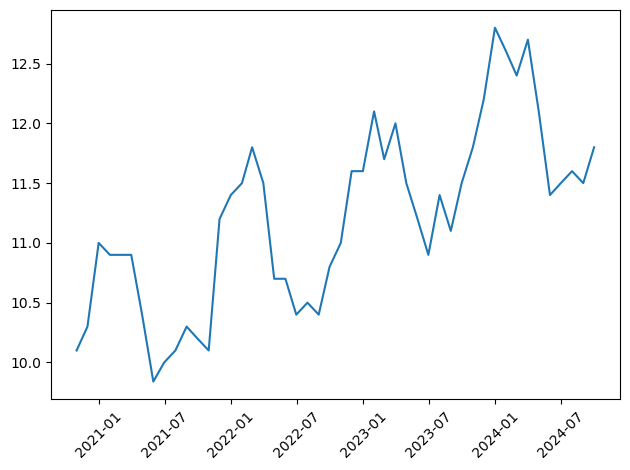

In [28]:
plt.plot(df["ds"], df["y"])
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [29]:
"""here I decided to Use profet model for the time-series forecasting since we have a plot with obvious seasonality since it is more convenient and 
produces similar as the classical SARIMA model"""

'here I decided to Use profet model for the time-series forecasting since we have a plot with obvious seasonality since it is more convenient and \nproduces similar as the classical SARIMA model'

In [31]:
# Train & forecast
model = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
model.fit(df)
forecast = model.predict(model.make_future_dataframe(periods=12, freq="MS"))

22:19:28 - cmdstanpy - INFO - Chain [1] start processing
22:19:28 - cmdstanpy - INFO - Chain [1] done processing


   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
    --------------------------------------- 0.3/12.1 MB ? eta -:--:--
   - -------------------------------------- 0.5/12.1 MB 1.1 MB/s eta 0:00:11
   - -------------------------------------- 0.5/12.1 MB 1.1 MB/s eta 0:00:11
   -- ------------------------------------- 0.8/12.1 MB 916.7 kB/s eta 0:00:13
   --- ------------------------------------ 1.0/12.1 MB 961.4 kB/s eta 0:00:12
   ---- ----------------------------------- 1.3/12.1 MB 1.0 MB/s eta 0:00:11
   ---- ----------------------------------- 1.3/12.1 MB 1.0 MB/s eta 0:00:11
   ---- ----------------------------------- 1.3/12.1 MB 1.0 MB/s eta 0:00:11
   ---- ----------------------------------- 1.3/12.1 MB 1.0 MB/s eta 0:00:11
   ---- ----------------------------------- 1.3/12.1 MB 1.0 MB/s eta 0:00:11
   ---- ----------------------------------- 1.3/12.1 MB 1.0 MB/s eta 0:00:11
   ---- --------

In [32]:
def estimate_gas_price(date_input):
    query_date = pd.to_datetime(date_input)
    closest = forecast.loc[(forecast["ds"] - query_date).abs().idxmin()]
    return {
        "date":  closest["ds"].strftime("%Y-%m-%d"),
        "price": round(closest["yhat"], 4),
        "lower": round(closest["yhat_lower"], 4),
        "upper": round(closest["yhat_upper"], 4),
    }

print(estimate_gas_price("2024-06-01"))

{'date': '2024-05-31', 'price': np.float64(11.3784), 'lower': np.float64(11.1964), 'upper': np.float64(11.5582)}


In [ ]:
""" here I finished the first activity where we did not just make a single estimation of the price but rather a more 